### Let's run intron clustering to annotate alternative splicing events given observed junctions in our cells 

In [2]:
!hostname

pe2cc2-075.c.nygenome.org


In [3]:
import os
import pandas as pd 
from sklearn.decomposition import TruncatedSVD
import anndata as ad
from scipy.sparse import coo_matrix
from datetime import datetime

# turn this into AnnData object 
import anndata as ad
from scipy.sparse import csr_matrix
import numpy as np
import torch 
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

from scipy.spatial.distance import cdist

import numpy as np

import sys
import os
import json
import numpy as np
import torch
import anndata as ad
from importlib import reload
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import pyro 
import umap.umap_ as umap
import matplotlib.patches as mpatches
import scipy.sparse
import datetime
import sys
import random

# Import custom modules
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor')

import factor_model
reload(factor_model)

import waypoints_prep_input as wayp
reload(wayp)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

float_type = {"device": device, "dtype": torch.float}
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

!hostname

2.3.0+cu121
12.1
2.3.0+cu121
12.1
Using device: cpu
pe2cc2-075.c.nygenome.org


### Specify if we want to prep brain only file or ALL tissue file


In [4]:
gtf_annot=True
filter_junctions=True 
gtf_file = "/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-reference/gencode/gencode.v45.primary_assembly.annotation.gtf"

### Load merged anndata file containing all cells

In [5]:
WD="/gpfs/commons/projects/knowles_singlecell_splicing/PRJEB14362/LeafletFA/ATSEs"
anndata="ATSE_Anndata_noGTF_Object_20241127_151430.h5ad"
input_file=f"{WD}/{anndata}"

adata_full = ad.read_h5ad(input_file)
splice_adata = adata_full.copy()
splice_adata.obs.reset_index(drop=True, inplace=True)
splice_adata.obs["cell_id_index"] = splice_adata.obs.index 

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [6]:
# Note: this ATSE file was also generated through the script mentioned above
atses="iPSC_human_cells_with_annotations_50_500000_500_20241126_single_cell.gz"
ATSE_file=f"{WD}/{atses}"
atses = pd.read_csv(ATSE_file, sep="}")

In [7]:
splice_adata.obs.reset_index(drop=True, inplace=True)
splice_adata.obs["cell_id_index"] = splice_adata.obs.index 
print(splice_adata.obs.shape, splice_adata.obs.cell_id_index.max())

(43107, 11) 43106


### Merge ATSE gene information if it's there to splice_adata object!

In [8]:
if gtf_annot:
    splice_adata.var = splice_adata.var.merge(atses[["gene_id", "gene_name", "junction_id"]], on=["gene_id", "junction_id"])
else:
    splice_adata.var = splice_adata.var.merge(atses[["junction_id"]], on=["junction_id"])    

### Fix "day" variable, add "none" where it is not specified 

In [9]:
# Assign "unknown" to "day" which is a categorical column that's missing a value 
# add "unknown" to the list of categories
splice_adata.obs["day"] = splice_adata.obs["day"].astype("category")
splice_adata.obs["day"] = splice_adata.obs["day"].cat.add_categories("unknown")
splice_adata.obs["day"].fillna("unknown", inplace=True)

/scratch/ipykernel_24089/2309579728.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  splice_adata.obs["day"].fillna("unknown", inplace=True)


In [10]:
splice_adata.obs

,cell_id,cell_name,library_name,donor,day,experiment,plate_id,plate_well_id,donor_short_id,donor_long_id,cell_id_index
0,ERR1462990,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN,0
1,ERR1463032,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN,1
2,ERR1463068,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN,2
3,ERR1463185,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN,3
4,ERR1463369,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN,4
...,...,...,...,...,...,...,...,...,...,...,...
43102,ERR4361569,24327_5#278,NT1200673M,suop,day1,expt_30,2039.0,2039_L14,suop_5,HPSI0914i-suop_5,43102
43103,ERR4361592,24327_5#301,NT1200696T,sehl,day1,expt_30,2039.0,2039_M13,sehl_6,HPSI1014i-sehl_6,43103
43104,ERR4361738,24327_6#63,NT1211045W,poih,day0,expt_28,1787.0,1787_C15,poih_4,HPSI0214i-poih_4,43104
43105,ERR4361890,24327_6#215,NT1211197O,poih,day0,expt_28,1787.0,1787_I23,poih_4,HPSI0214i-poih_4,43105


### Obtain sparse junction usage ratios! (First filter to keep only junctions with reasonable coverage...)

In [11]:
# Extract junction counts and cluster counts as sparse matrices
junction_counts = splice_adata.layers["cell_by_junction_matrix"] 
junction_counts = junction_counts.tocoo()

cluster_counts = splice_adata.layers["cell_by_cluster_matrix"]    
cluster_counts = cluster_counts.tocoo()

### Ensure we are only keeping ATSEs for downstream analysis with at least two junctions post filtering 

In [12]:
if filter_junctions:

    # Filter junctions, ensuring they have reasonable coverage 
    junc_norm_sum = wayp.sparse_sum(junction_counts, 0) / junction_counts.shape[0]
    min_junc_mean = 0.005 # default 
    to_keep = junc_norm_sum > min_junc_mean
    juncs_filter = splice_adata.var[to_keep]

    print(f"Number of junctions in matrix before filtering: {len(junc_norm_sum)}")
    print(f"Number of junctions after filtering {len(junc_norm_sum[to_keep])}")

    cluster_junction_counts = juncs_filter.groupby("Cluster")["junction_id"].count()
    clusters_to_keep = cluster_junction_counts[cluster_junction_counts >= 2].index
    juncs_filter_final = juncs_filter[juncs_filter["Cluster"].isin(clusters_to_keep)]

    splice_adata.var['old_index'] = splice_adata.var.index
    splice_adata = splice_adata[:, juncs_filter_final.index]
    splice_adata.var = splice_adata.var.reset_index(drop=True)
    splice_adata.var["junction_id_index"] = splice_adata.var.index

Number of junctions in matrix before filtering: 30452
Number of junctions after filtering 30452


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


### Now make sure there are no cells wtih zero counts across the board!

In [13]:
# Access the sparse matrix with junction counts (assumed to be in layers['cell_by_junction_matrix'])
junction_matrix = splice_adata.layers['cell_by_junction_matrix']

# Check if the matrix is sparse (it should be sparse to avoid conversion to dense)
if isinstance(junction_matrix, csr_matrix):
    # Sum across each row (axis=1) and check if the sum is zero (meaning the row is all zeros)
    non_zero_cells = junction_matrix.getnnz(axis=1) > 0
else:
    raise ValueError("The matrix is not sparse!")

print(len(non_zero_cells))

# Filter the AnnData object to remove cells with all zero counts
splice_adata = splice_adata[non_zero_cells, :]

43107


#### Get sparse PCA, UMAP and Diffusion Map!

In [14]:
# Extract junction counts and cluster counts as sparse matrices 
# junction_counts = splice_adata.layers["cell_by_junction_matrix"] 
# cluster_counts = splice_adata.layers["cell_by_cluster_matrix"]    

# Ensure the matrices are in COO format for easier element-wise operations
# junction_counts = junction_counts.tocoo()
# cluster_counts = cluster_counts.tocoo()

In [15]:
splice_adata.layers["cell_by_cluster_matrix"]

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 263731629 stored elements and shape (43107, 30452)>

In [16]:
splice_adata.X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 263731629 stored elements and shape (43107, 30452)>

In [17]:
# Get sparse centered PSI values 
splice_adata.layers["junc_ratio"] = wayp.calculate_centered_psi(junction_counts, cluster_counts)

# Step 1: Perform PCA using sparse data
n_components = 40  # Number of components to keep

n_iter = 5  # Increasing the number of iterations for better convergence
svd = TruncatedSVD(n_components=n_components, n_iter=n_iter, random_state=42)

# Fit and transform the junction ratio data (this gives U)
U = svd.fit_transform(splice_adata.layers["junc_ratio"])

# Get the singular values (S)
S = svd.singular_values_

# Multiply U by S to get U * S
# Need to scale U by the singular values S (broadcasted across columns)
U_by_S = U * S  # This scales each component in U by the corresponding singular value in S

# Store the PCA results (U * S) in the 'X_pca' field of .obsm (multi-dimensional)
splice_adata.obsm['X_pca'] = U_by_S

# Optionally, store explained variance ratio for future reference
splice_adata.uns['pca_explained_variance_ratio'] = svd.explained_variance_ratio_

/scratch/ipykernel_24089/450472730.py:2: ImplicitModificationWarning: Setting element `.layers['junc_ratio']` of view, initializing view as actual.
  splice_adata.layers["junc_ratio"] = wayp.calculate_centered_psi(junction_counts, cluster_counts)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [18]:
pca_result = U_by_S

# Step 2: Compute UMAP on the PCA-reduced data
sc.pp.neighbors(splice_adata, use_rep='X_pca')

# Step 3. Calculate UMAP 
sc.tl.umap(splice_adata)

# Step 4. Calculate the diffusion map
sc.tl.diffmap(splice_adata)

# The diffusion components are now stored in adata.obsm['X_diffmap']
diffmap_components = splice_adata.obsm['X_diffmap']
pca_components = splice_adata.obsm["X_pca"]

# Step 5. Run tSNE 
sc.tl.tsne(splice_adata)
tsne_components = splice_adata.obsm["X_tsne"]

### Identify cell waypoints using splicing based PCs!

In [19]:
# Define possible number of waypoints to learn
n_waypoints_learn = [30, 50]

# Placeholder to store waypoints and metacell dictionaries for each n_waypoints
waypoints_dict = {}
metacell_dicts = {}

# Parameters
num_components = 10  # Number of diffusion map components to consider
metacell_size = 50    # Number of nearest cells to assign to each waypoint

# Loop over different n_waypoints to generate waypoints and metacell assignments
for n_waypoints in n_waypoints_learn:

    print(f"Finding {n_waypoints} waypoints from the diffusion components!")
    random_seed = np.random.randint(0, 10000 + 1)  # Generate random seed
    
    # Max-min sampling to identify waypoints
    waypoints = wayp.max_min_sampling(pca_components, n_waypoints, num_components=num_components, seed=random_seed)
    
    # Store waypoints for this particular number of waypoints
    waypoints_dict[n_waypoints] = waypoints

    # Assign nearest cells to each waypoint (metacells)
    metacell_dict = wayp.assign_nearest_cells(waypoints, pca_components, num_nearest=metacell_size)
    
    # Store the metacell dictionary for this number of waypoints
    metacell_dicts[n_waypoints] = metacell_dict

Finding 30 waypoints from the diffusion components!
Finding 50 waypoints from the diffusion components!


#### Try looking at waypoints just using PC space...

In [20]:
reload(wayp)

<module 'waypoints_prep_input' from '/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/waypoints_prep_input.py'>

In [21]:
splice_adata.obs.library_name.value_counts()

library_name
NT851876S     1
NT1313888C    1
NT1313898E    1
NT1313897D    1
NT1313896C    1
             ..
NT1215097E    1
NT1215096D    1
NT1215095C    1
NT1215094B    1
NT1376787R    1
Name: count, Length: 23790, dtype: int64

... storing 'gene_id' as categorical
... storing 'gene_name' as categorical


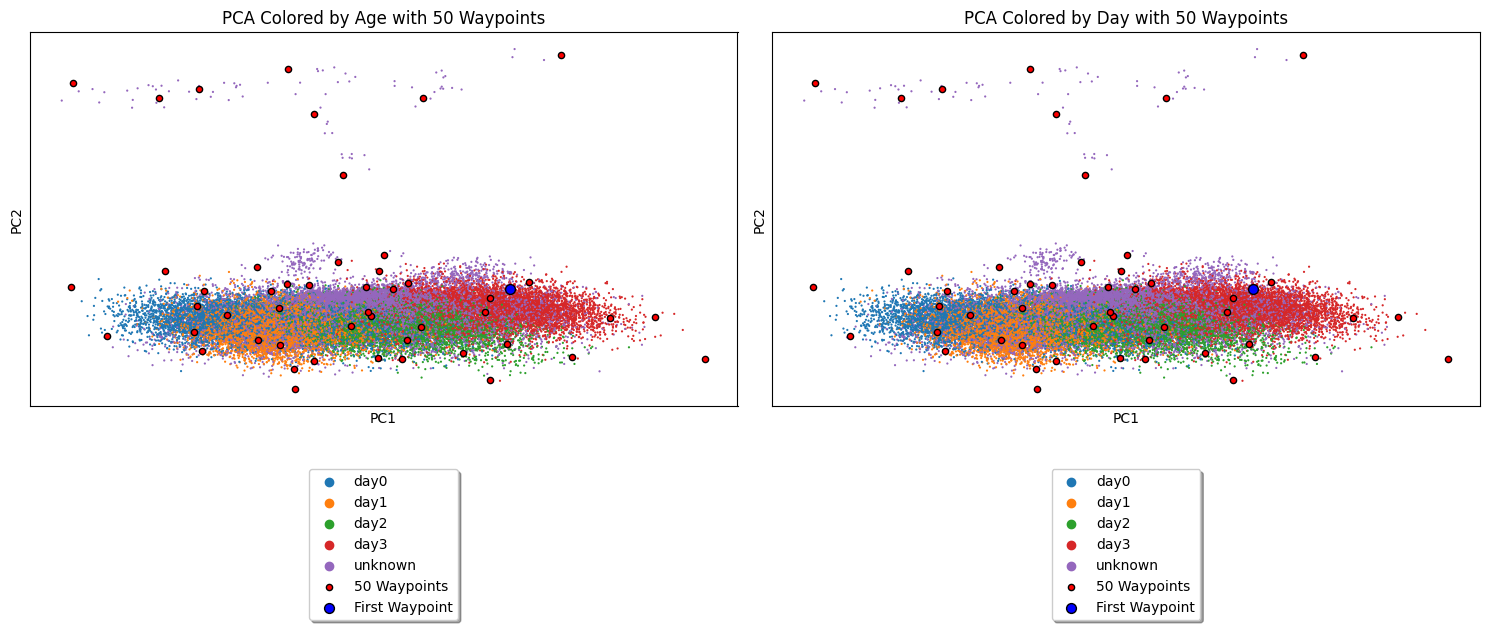

In [22]:
wayp.plot_PCA_with_waypoints(splice_adata, waypoints_dict, color_by="day", n_waypoints=50, waypoint_color='red', first_waypoint_color='blue', size=10, second_color='day')
# wayp.plot_tSNE_with_waypoints(splice_adata, waypoints_dict, color_by="day", n_waypoints=50, waypoint_color='red', first_waypoint_color='blue', size=10)
# wayp.plot_UMAP_with_waypoints(splice_adata, waypoints_dict, color_by="day", n_waypoints=50, waypoint_color='red', first_waypoint_color='blue', size=10)

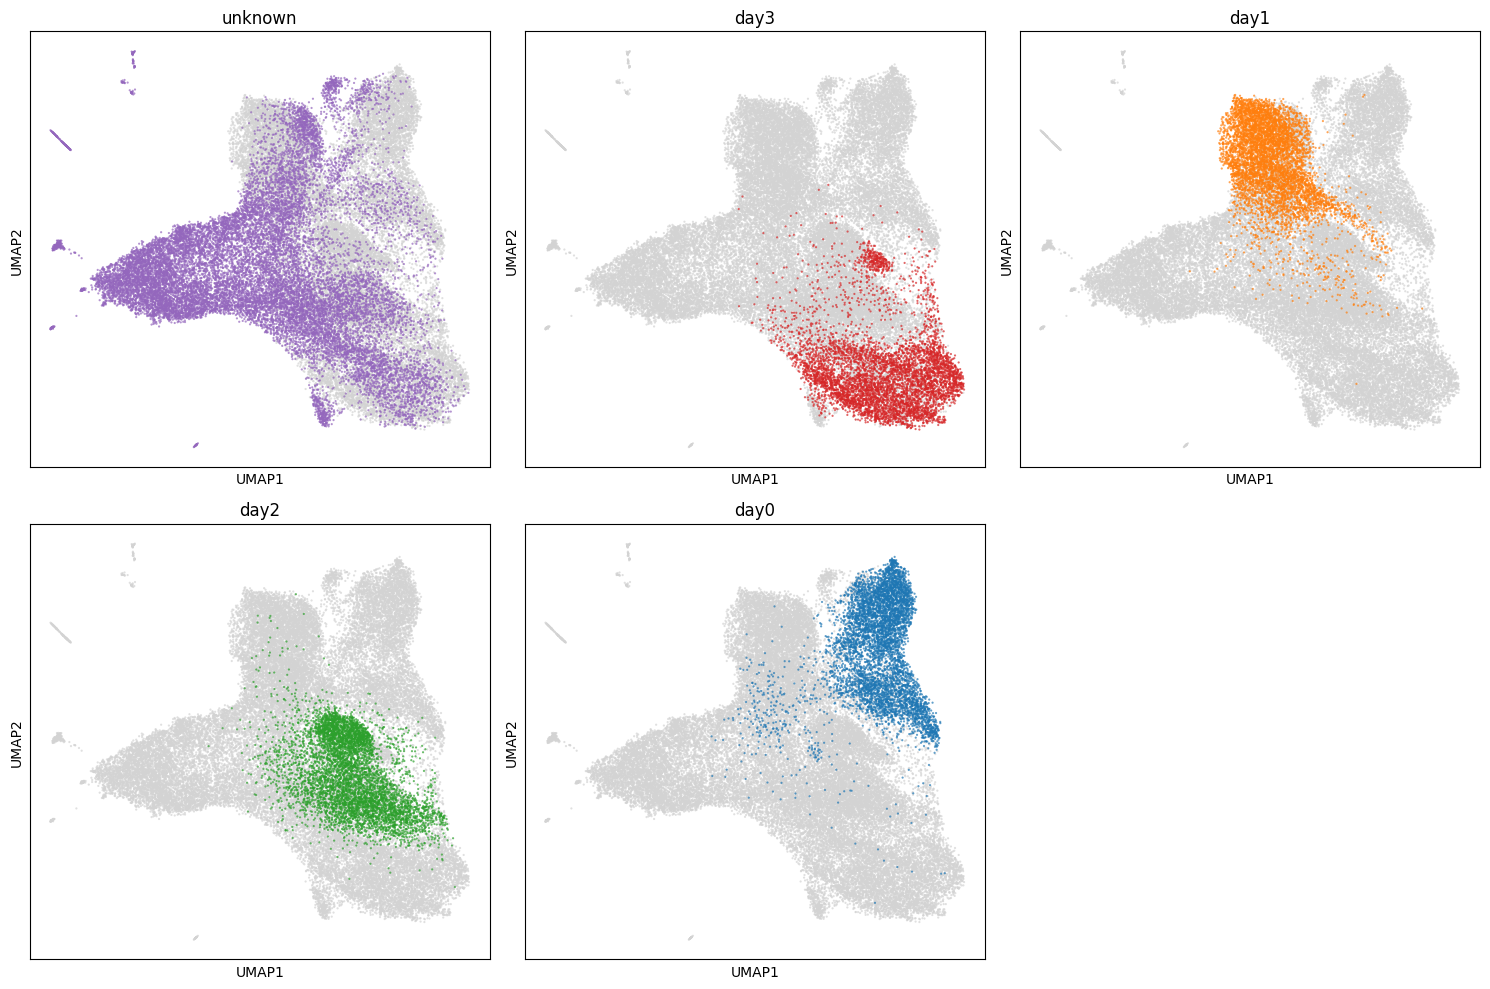

In [23]:
# Get the unique tissues in adata.obs['cell_ontology_class']
days = splice_adata.obs['day'].unique()

# Set up grid dimensions: 6 rows, adjust columns to fit the number of tissues
n_days = len(days)
n_rows = 2  
n_cols = int(np.ceil(n_days / n_rows))  # Calculate the number of columns needed

# Create a grid of subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5))  # Adjust figure size as needed
axes = axes.flatten()  # Flatten axes to easily loop through them

# Plot each tissue's UMAP in its subplot without legend
for i, tissue in enumerate(days):
    ax = axes[i]
    
    # Plot UMAP for the specific tissue on the corresponding subplot without the legend
    sc.pl.umap(splice_adata, color="day", groups=[tissue], show=False, size=10, alpha=0.7, ax=ax, legend_loc="none")
    
    # Set title for each subplot with the tissue name
    ax.set_title(tissue)

# Turn off unused axes if there are any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout for better spacing
plt.tight_layout()

# Show the combined grid of plots
plt.show()

### Generate_initializations matrices for Phi and Psi

In [24]:
rho_hat = splice_adata.layers["junc_ratio"]

# Generate multiple initializations
psi_initializations, phi_initializations = wayp.generate_initializations(rho_hat, waypoints_dict, metacell_dicts, epsilon=0.001)

Finding 30 waypoints from the diffusion components!


30it [00:35,  1.17s/it]


Finding 50 waypoints from the diffusion components!


50it [00:57,  1.15s/it]


In [25]:
# Loop through the waypoints_dict and corresponding initializations
for i, n_waypoints in enumerate(waypoints_dict.keys()):

    print(f"Adding waypoint based initializations to anndata for {n_waypoints} waypoints!")

    # Extract the corresponding psi and phi initializations
    psi = psi_initializations[i]
    phi = phi_initializations[i]

    # Convert psi and phi to torch tensors if needed
    psi = torch.tensor(psi)
    phi = torch.tensor(phi)

    # Convert to NumPy arrays if psi and phi are torch tensors (just in case)
    if isinstance(psi, torch.Tensor):
        psi = psi.cpu().numpy()  # Convert to NumPy array
    if isinstance(phi, torch.Tensor):
        phi = phi.cpu().numpy()  # Convert to NumPy array

    # Store psi in `adata.varm` and phi in `adata.obsm` with keys based on the number of waypoints
    splice_adata.varm[f'psi_init_{n_waypoints}_waypoints'] = psi  # Store psi with name 'psi_init_{n_waypoints}_waypoints'
    splice_adata.obsm[f'phi_init_{n_waypoints}_waypoints'] = phi  # Store phi with name 'phi_init_{n_waypoints}_waypoints'


Adding waypoint based initializations to anndata for 30 waypoints!
Adding waypoint based initializations to anndata for 50 waypoints!


In [26]:
# Convert the 'junc_ratio' layer to a CSR matrix before saving
if isinstance(splice_adata.layers['junc_ratio'], coo_matrix):
    splice_adata.layers['junc_ratio'] = splice_adata.layers['junc_ratio'].tocsr()

### Save splice_adata Anndata object

In [27]:
input_file

'/gpfs/commons/projects/knowles_singlecell_splicing/PRJEB14362/LeafletFA/ATSEs/ATSE_Anndata_noGTF_Object_20241127_151430.h5ad'

In [28]:
# Original file path
original_path = input_file  # Input your original file path

# Extract the directory and filename
base_directory = os.path.dirname(original_path)
original_filename = os.path.basename(original_path)

# Get the current date and time as a string (format: YYYYMMDD_HHMMSS)
timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')

# Replace the date and timestamp part with "with_initializations" and append the new timestamp
filename_parts = original_filename.split('_')

# Conditionally add "brain_only" to the file name if brain_only is True
if gtf_annot:
    new_filename = f"{'_'.join(filename_parts[:-2])}_with_initializations_wGTFannot_{timestamp}.h5ad"
else:
    new_filename = f"{'_'.join(filename_parts[:-2])}_with_initializations_wNoGTFannot_{timestamp}.h5ad"

print(new_filename)

# Create the new full file path
new_file_path = os.path.join(base_directory, new_filename)

# Save the AnnData object with the new filename
splice_adata.write_h5ad(new_file_path, compression='gzip')

print(f"AnnData saved as {new_file_path}")

ATSE_Anndata_noGTF_Object_with_initializations_wGTFannot_20241203_111855.h5ad
AnnData saved as /gpfs/commons/projects/knowles_singlecell_splicing/PRJEB14362/LeafletFA/ATSEs/ATSE_Anndata_noGTF_Object_with_initializations_wGTFannot_20241203_111855.h5ad
